In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
class linear_regression: 
    def __init__(self, w, b, learning_rate):
        self.x = None 
        self.y = None 
        self.alpha = learning_rate
        self.w = w
        self.b = b
        
    def generate_sample_data(self):
        # Generate random data for X
        self.x = np.linspace(1, 100, 100)  # 100 data points between 1 and 100
        
        # Define a linear relationship with some noise
        true_slope = 4
        true_intercept = 100
        noise = np.random.randn(100) * 50  # Adding random noise
        
        # Generate target Y values
        self.y = true_slope * self.x + true_intercept + noise

    def plot_sample_data(self):
        # Plot the data
        plt.figure(figsize=(5, 5))
        plt.scatter(self.x, self.y, color='blue', label='Sample Data')
        
        # Add labels and title
        plt.xlabel('House Size (square feet)')
        plt.ylabel('House Price ($)')
        plt.title('Scatter Plot of Sample Data: House Size vs Price')
        
        # Show legend and grid
        plt.legend()
        plt.grid(True)
        
        # Show the plot
        plt.show()

    def linear_regression_predict(self):
        equation_linear_regression = self.w * self.x + self.b # i think it's ok if i don't use dot product here 
        return equation_linear_regression


    def quality_check(self):
        # i am thinking about using R^2 here cuz it is better to interpret 
        mean_value = np.mean(self.y)
        numerator = np.sum((self.y - self.linear_regression_predict()) ** 2)
        denomator = np.sum((self.y - mean_value) ** 2)
        r_square = 1 - ( numerator / denomator )
        r_square = round(r_square, 6)
        return r_square

    def optimize(self, count):
        """ 
        cost function -> 1/2m * (np.sum(linear_regression_predict - self.y)^2)
        gradient descent for parameter w -> 1/m * (np.sum((linear_regression_predict - self.y[i]) * self.x[i]))
        gradient descent for parameter b -> 1/m * (np.sum(linear_regression_predict - self.y[i]))
        NOTE: linear_regression should have the same length as the self.y to be able to calculate element wise
        """

        m = len(self.x)
        
        for i in range(count):
            error = self.linear_regression_predict() - self.y
                
            optimize_w = 1/m * np.sum(error * self.x)
            optimize_b = 1/m * np.sum(error)
            
            self.w = self.w - self.alpha * optimize_w
            self.b = self.b - self.alpha * optimize_b
            
            
    def plot_final_graph(self):
        plt.figure(figsize=(5, 5))
        plt.scatter(self.x, self.y, color='blue', label='Sample Data')
        
        plt.xlabel('House Size (square feet)')
        plt.ylabel('House Price ($)')
        plt.title('Scatter Plot of Sample Data: House Size vs Price')    

        plt.plot(self.x, self.linear_regression_predict(), color='red', label='Fitted Line')
        
        plt.legend()
        plt.grid(True)
        plt.show()
            

In [18]:
model = linear_regression(0, 0, 0.0001)
model.generate_sample_data()

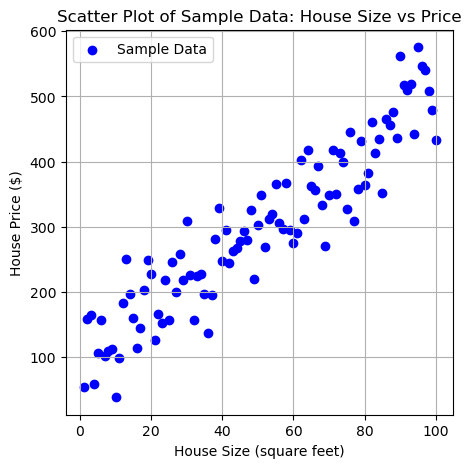

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [56]:
model.plot_sample_data()
model.linear_regression_predict()

this is the count that will be used in loop: 10000
5.16207226956015
20.440418137162872
how good the model is: 78.0009%


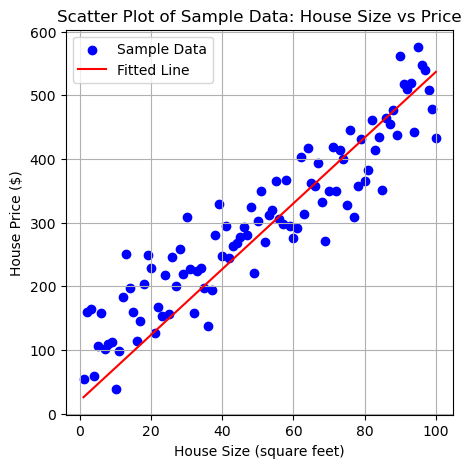

In [58]:
count = len(model.x) ** 2 
print(f"this is the count that will be used in loop: {count}")
model.optimize(count)
print(model.w)
print(model.b)
print(f"how good the model is: {model.quality_check() * 100}%")
model.plot_final_graph()

this is the count that will be used in loop: 1500000
4.073568016440499
93.36489607096482
how good the model is: 86.1619%


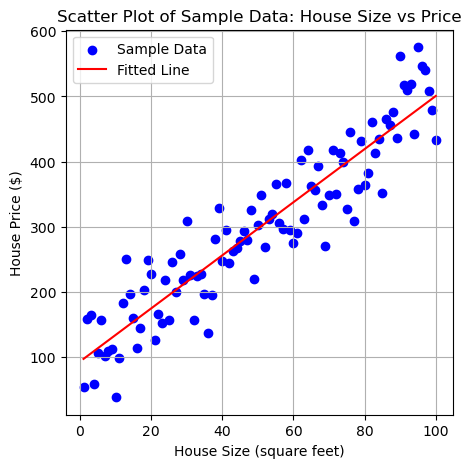

In [60]:
"""
NOTE: this is the best fit line. 
how do i know this is the best fit? cuz the slope and y-intercept that I used for sample data is 4 and 100.
"""
count = (len(model.x) ** 2 ) * 150
print(f"this is the count that will be used in loop: {count}")
model.optimize(count)
print(model.w)
print(model.b)
print(f"how good the model is: {model.quality_check() * 100}%")
model.plot_final_graph()